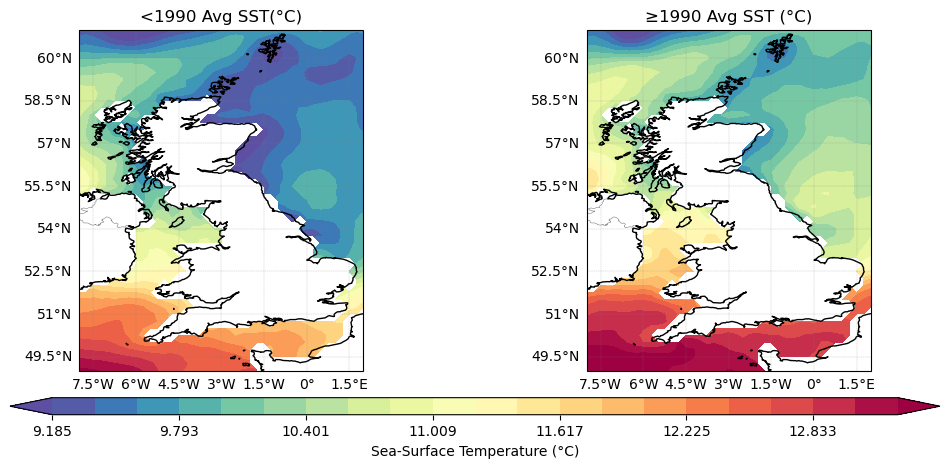

In [5]:
# Importing relevant modules
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr
import numpy as np

file_path_b = r"C:\Users\itsna\OneDrive\Desktop\MSc Work\DataSets\data_stream-moda_stepType-avgua.nc"

# Choosing colourmap
colour_map = "Spectral_r"

# Opening temp dataset
ds = xr.open_dataset(file_path_b)

# Variable and coordinate names
time_name = "valid_time"
lat_name  = "latitude"
lon_name  = "longitude"
sst_name  = "sst"

# Converting to celsius
sstK = ds[sst_name]
sstC = sstK - 273.15

# Time and year arrays
time_da = ds[time_name]
years = time_da.dt.year

# Splitting into pre and post 1990 and taking time avg
sst_preC  = sstC.where(years < 1990,  drop=True).mean(time_name, skipna=True)
sst_postC = sstC.where(years >= 1990, drop=True).mean(time_name, skipna=True)

# Setting region (UK)
lon_min, lon_max = -8, 2
lat_min, lat_max = 49, 61

# Func to crop fields to region
def crop_to_region(da, lon_min, lon_max, lat_min, lat_max):
    lats = da[lat_name]
    lons = da[lon_name]

    # Latitude slice
    if lats[0] < lats[-1]:
        lat_slice = slice(lat_min, lat_max)
    else:
        lat_slice = slice(lat_max, lat_min)

    # Longitude slice
    if lons[0] < lons[-1]:
        lon_slice = slice(lon_min, lon_max)
    else:
        lon_slice = slice(lon_max, lon_min)

    return da.sel({lat_name: lat_slice, lon_name: lon_slice})

# Cropping fields to UK
sst_pre_reg  = crop_to_region(sst_preC,  lon_min, lon_max, lat_min, lat_max)
sst_post_reg = crop_to_region(sst_postC, lon_min, lon_max, lat_min, lat_max)

# Shared colour limits from cropped fields
stack = np.concatenate([
    sst_pre_reg.values.ravel(),
    sst_post_reg.values.ravel()
])
vmin = np.nanpercentile(stack, 2)
vmax = np.nanpercentile(stack, 98)
levels = np.linspace(vmin, vmax, 21)

# Extracting lon/lat for plotting
lon_reg = sst_pre_reg[lon_name]
lat_reg = sst_pre_reg[lat_name]

# Choosing map projection
proj = ccrs.PlateCarree()

# Plotting pre1990 vs post1990 SST
fig = plt.figure(figsize=(12, 5))
gs = fig.add_gridspec(nrows=2, ncols=2, height_ratios=[20, 1], hspace=0.15)

# Map axes
ax_pre  = fig.add_subplot(gs[0, 0], projection=proj)
ax_post = fig.add_subplot(gs[0, 1], projection=proj)

# Colourbar axis
cax = fig.add_subplot(gs[1, :])

# Map settings
for ax in [ax_pre, ax_post]:
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
    ax.coastlines(resolution="10m", color="black")
    ax.add_feature(cfeature.BORDERS, linewidth=0.4, edgecolor="gray")

    gl = ax.gridlines(
        draw_labels=True,
        linewidth=0.3,
        linestyle="--",
        color="gray",
        alpha=0.5,
        x_inline=False,
        y_inline=False,
    )
    gl.top_labels = False
    gl.right_labels = False

# Plotting
cs_pre = ax_pre.contourf(
    lon_reg, lat_reg, sst_pre_reg,
    levels=levels, cmap=colour_map,
    transform=proj, extend='both'
)
ax_pre.set_title("<1990 Avg SST(°C)")

cs_post = ax_post.contourf(
    lon_reg, lat_reg, sst_post_reg,
    levels=levels, cmap=colour_map,
    transform=proj, extend='both'
)
ax_post.set_title("≥1990 Avg SST (°C)")

# Colourbar
cbar = fig.colorbar(cs_post, cax=cax, orientation="horizontal")
cbar.set_label("Sea-Surface Temperature (°C)")

plt.show()


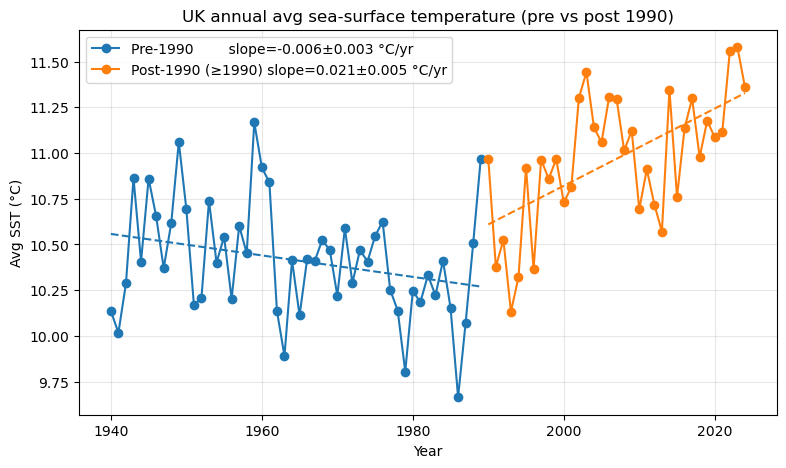

In [6]:
# Importing relevant modules
from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr

file_path_b = r"C:\Users\itsna\OneDrive\Desktop\MSc Work\DataSets\data_stream-moda_stepType-avgua.nc"

# Opening temp dataset
ds = xr.open_dataset(file_path_b)

# Defining names
time_name = "valid_time"
lat_name  = "latitude"
lon_name  = "longitude"
sst_name  = "sst"

# Def linear model
def linear_model(x, m, b):
    return m * x + b

# Func to crop to UK region only
def crop_to_region_3d(da, lon_min, lon_max, lat_min, lat_max):
    lats = da[lat_name]
    lons = da[lon_name]

    # Latitude slice
    if lats[0] < lats[-1]:
        lat_slice = slice(lat_min, lat_max)
    else:
        lat_slice = slice(lat_max, lat_min)

    # Longitude slice
    if lons[0] < lons[-1]:
        lon_slice = slice(lon_min, lon_max)
    else:
        lon_slice = slice(lon_max, lon_min)

    return da.sel({lat_name: lat_slice, lon_name: lon_slice})

# Extracting time array
time_index = pd.to_datetime(ds[time_name].values)

# Setting UK region
lon_min, lon_max = -8, 2
lat_min, lat_max = 49, 61

# Cropping SST and connverting to C
sstK = ds[sst_name]
sstK_uk = crop_to_region_3d(sstK, lon_min, lon_max, lat_min, lat_max)
sstC_uk = sstK_uk - 273.15

# Monthly UK avg
sst_monthly = np.nanmean(sstC_uk.values, axis=(1, 2))

# Annual avgs
n_months = len(time_index)
n_years  = n_months // 12

sst_trim = sst_monthly[:n_years * 12].reshape(n_years, 12).mean(axis=1)

# Corresponding year for each annual avg
y0 = int(time_index[0].year)
years = np.arange(y0, y0 + n_years).astype(float)

# Splitting into pre/post 1990
mask_pre  = years < 1990
mask_post = years >= 1990

years_pre  = years[mask_pre]
years_post = years[mask_post]

sst_pre  = sst_trim[mask_pre]
sst_post = sst_trim[mask_post]

# Fit helper func
def fit_series(x, y):
    mask = np.isfinite(x) & np.isfinite(y)
    x_fit, y_fit = x[mask], y[mask]
    popt, pcov = curve_fit(linear_model, x_fit, y_fit)
    m, b = popt
    m_se = float(np.sqrt(pcov[0, 0]))
    return m, b, m_se, x_fit, y_fit

# Linear fits for pre/post 1990
m_pre,  b_pre,  se_pre,  x_pre_fit,  y_pre_fit  = fit_series(years_pre,  sst_pre)
m_post, b_post, se_post, x_post_fit, y_post_fit = fit_series(years_post, sst_post)

# Plotting
fig, ax = plt.subplots(figsize=(9, 5))

ln_pre, = ax.plot(x_pre_fit, y_pre_fit, 'o-',
                  label=f"Pre-1990        slope={m_pre:.3f}±{se_pre:.3f} °C/yr")
ax.plot(x_pre_fit, linear_model(x_pre_fit, m_pre, b_pre),
        '--', color=ln_pre.get_color())

ln_post, = ax.plot(x_post_fit, y_post_fit, 'o-',
                   label=f"Post-1990 (≥1990) slope={m_post:.3f}±{se_post:.3f} °C/yr")
ax.plot(x_post_fit, linear_model(x_post_fit, m_post, b_post),
        '--', color=ln_post.get_color())

ax.set_xlabel('Year')
ax.set_ylabel('Avg SST (°C)')
ax.set_title('UK annual avg sea-surface temperature (pre vs post 1990)')
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()


Number of monthly UK-mean SST values < 1990:  600
Number of monthly UK-mean SST values ≥ 1990: 430


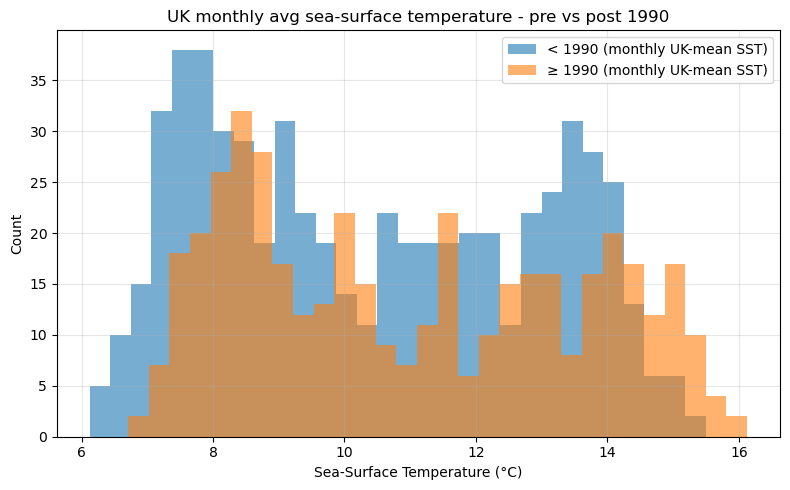

In [9]:
import pandas as pd
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

time_name = "valid_time"
lat_name  = "latitude"
lon_name  = "longitude"
sst_name  = "sst"

# UK region
lon_min, lon_max = -8, 2
lat_min, lat_max = 49, 61

# Cropping to UK region
sstK = ds[sst_name]
sstK_reg = crop_to_region_3d(sstK, lon_min, lon_max, lat_min, lat_max)

# Convertinig to C
sstC_reg = sstK_reg - 273.15

# Monthly avgs
# Avg over lat/lon for each timestep
sst_monthly_C = np.nanmean(sstC_reg.values, axis=(1, 2))

# Time / year array
time = pd.to_datetime(ds[time_name].values)
years = time.year.values

# Splitting into pre/post 1990
mask_pre  = years < 1990
mask_post = years >= 1990

sst_pre  = sst_monthly_C[mask_pre]
sst_post = sst_monthly_C[mask_post]

print(f"Number of monthly UK-mean SST values < 1990:  {sst_pre.size}")
print(f"Number of monthly UK-mean SST values ≥ 1990: {sst_post.size}")

# Plotting
plt.figure(figsize=(8, 5))
bins = 30

plt.hist(sst_pre,  bins=bins, alpha=0.6, label="< 1990 (monthly UK-mean SST)")
plt.hist(sst_post, bins=bins, alpha=0.6, label="≥ 1990 (monthly UK-mean SST)")

plt.xlabel("Sea-Surface Temperature (°C)")
plt.ylabel("Count")
plt.title("UK monthly avg sea-surface temperature - pre vs post 1990")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
